In [49]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

num layers = n <br>
num experts = e <br>
hidden size = 4096 <br>
num heads = 32 <br>
seq length = 1024 <br>
FFN hidden size = 4096 <br>
max position embeddings = 2048 <br>

H - hidden size <br>
V - vocab size <br>
N - num layers <br>
E - num experts <br>
MPE - max positional embeddings <br>
GA - gating network <br>
<br>
MHA - multi head attention <br>
LN - layer norm <br>
FFN - feed forward network <br>
FFNH - FFN hidden size <br>
TFL - transformer layer <br>
<br>
Для плотной модели: 
$$
TokenEmbeddings = H * H  = 205852672 \\ 
PositionalEmbeddings = MPE * H  = 8388608 \\ 
$$
<br>

$$
MHA = 4 * H^2 = 67108864 \\
LN  = 4 * H = 16384 \\
FFN = 2 * H * FFNH = 33554432 \\
TFL = MHA + FFN + LN = 100679680 \\
$$

<br>

$$
AllParamsTransformer = N * TFL = N * 10067980 \\
AllParams = AllParamsTransformer + TokenEmbeddings + PositionalEmbeddings = N * 100679680 + 139460608 \\
\\
SIZE = 2 * AllParams / 2^30 = 2 * (N * 100679680 + 139460608) / 2^30 \approx 0.186 * N  + 0.26
$$

<br>

Для MoE:
$$
TokenEmbeddings = H * H  = 205852672 \\ 
PositionalEmbeddings = MPE * H  = 8388608 \\ 
$$
<br>

$$
MHA = 4 * H^2 = 67108864 \\
LN  = 4 * H = 16384 \\
FFN = E * 2 * H * FFNH = E * 33554432 \\
GA = H * E
TFL = MHA + FFN + GA + LN = 67125248 +  E * 33558528 \\
$$

<br>

$$
AllParamsTransformer = N * TFL = N * (67125248 +  E * 33558528) \\
AllParams = AllParamsTransformer + TokenEmbeddings + PositionalEmbeddings = N * (67125248 +  E * 33558528) + 139460608 \\
\\
SIZE = 2 * AllParams / 2^30 = 2 * (N * (67125248 +  E * 33558528) + 139460608) / 2^{30} \approx 0.063 * E * N + 0.13 * N + 0.26
$$

In [50]:
dp = pd.DataFrame(
    {
        "model size": [2.12,  3.98, 5.84],
        "num layers": [10, 20, 30],
        "gpu mem (GB)": [4.045, 5.921, 7.796],
        "latency (s)": [1.595, 1.595, 35.308],
        "tkroughput (tokens/s)": [15.049, 8.066, 1.813]
    }
)

tp = pd.DataFrame(
    {
        "model size": [2.12,  3.98,  5.84,  7.7 ,  9.56, 11.42, 13.28],
        "num layers": [10, 20, 30, 40, 50, 60, 70],
        "gpu mem (GB)": [2.469, 3.407, 4.345, 5.283, 6.221, 7.159, 8.097],
        "latency (s)": [12.757, 22.805, 32.713, 42.612, 52.456, 62.790, 72.455],
        "tkroughput (tokens/s)": [5.017, 2.806, 1.956, 1.502, 1.220, 1.019, 0.883] 
    }
)

dp_zero_nvme = pd.DataFrame(
    {
        "model size": [5.84,  9.56, 13.28],
        "num layers": [30, 50, 70],
        "gpu mem (GB)": [2.186, 2.187, 2.189],
        "latency (s)": [71.044, 126.881, 176.455],
        "tkroughput (tokens/s)": [0.338, 0.189, 0.136] 
    }
)

dp_zero_cpu = pd.DataFrame(
    {
        "model size": [5.84, 9.56, 13.28, 17.01, 20.72],
        "num layers": [30, 50, 70, 90, 110],
        "gpu mem (GB)": [6.999, 8.688,  8.689, 8.659, 8.660],
        "latency (s)": [7.900, 13.391, 17.440, 20.690, 23.828],
        "tkroughput (tokens/s)": [ 3.038, 1.792, 1.376, 1.160, 1.007]   
    }
)

tp_zero_cpu = pd.DataFrame(
    {
        "model size": [ 5.84, 9.56, 13.28, 17.01, 20.72],
        "num layers": [30, 50, 70, 90, 110],
        "gpu mem (GB)": [4.095, 4.846, 4.847, 4.848, 4.755],
        "latency (s)": [5.657, 8.480, 11.169, 13.579, 16.559],
        "tkroughput (tokens/s)": [4.243, 2.830, 2.149, 1.767, 1.449]          
        
    }
)

moe = pd.DataFrame(
    {
        "model size": [4.08,  6.6, 11.64, 21.72, 7.9, 12.94],
        "num layers": [10, 10, 10, 10, 20, 20],
        "num experts": [4, 8, 16, 32, 4, 8],
        "gpu mem (GB)": [4.358, 4.983, 6.234, 8.735, 6.546, 7.797],
        "latency (s)": [1.934, 1.935, 1.934, 1.937, 3.049, 3.681],
        "tkroughput (tokens/s)": [12.408, 12.403, 12.408, 12.391, 6.563, 6.519]        
    }
)

tp_moe = pd.DataFrame(
    {
        "model size": [ 4.08,  6.6 , 11.64, 21.72, 7.9, 12.94, 23.02],
        "num layers": [10, 10, 10, 10, 20, 20, 20],
        "num experts": [4, 8, 16, 32, 4, 8, 16],
        "gpu mem (GB)": [2.938, 3.563, 4.814, 7.315, 4.345, 5.595, 8.097],
        "latency (s)": [1.899, 1.892, 1.882, 1.959, 3.450, 3.412, 3.415],
        "tkroughput (tokens/s)": [12.641, 12.684, 12.752, 12.252, 6.957, 7.033, 7.027]      
    }
)




In [51]:
columns = ["gpu mem (GB)", "latency (s)", "tkroughput (tokens/s)"]

# Standard LLM

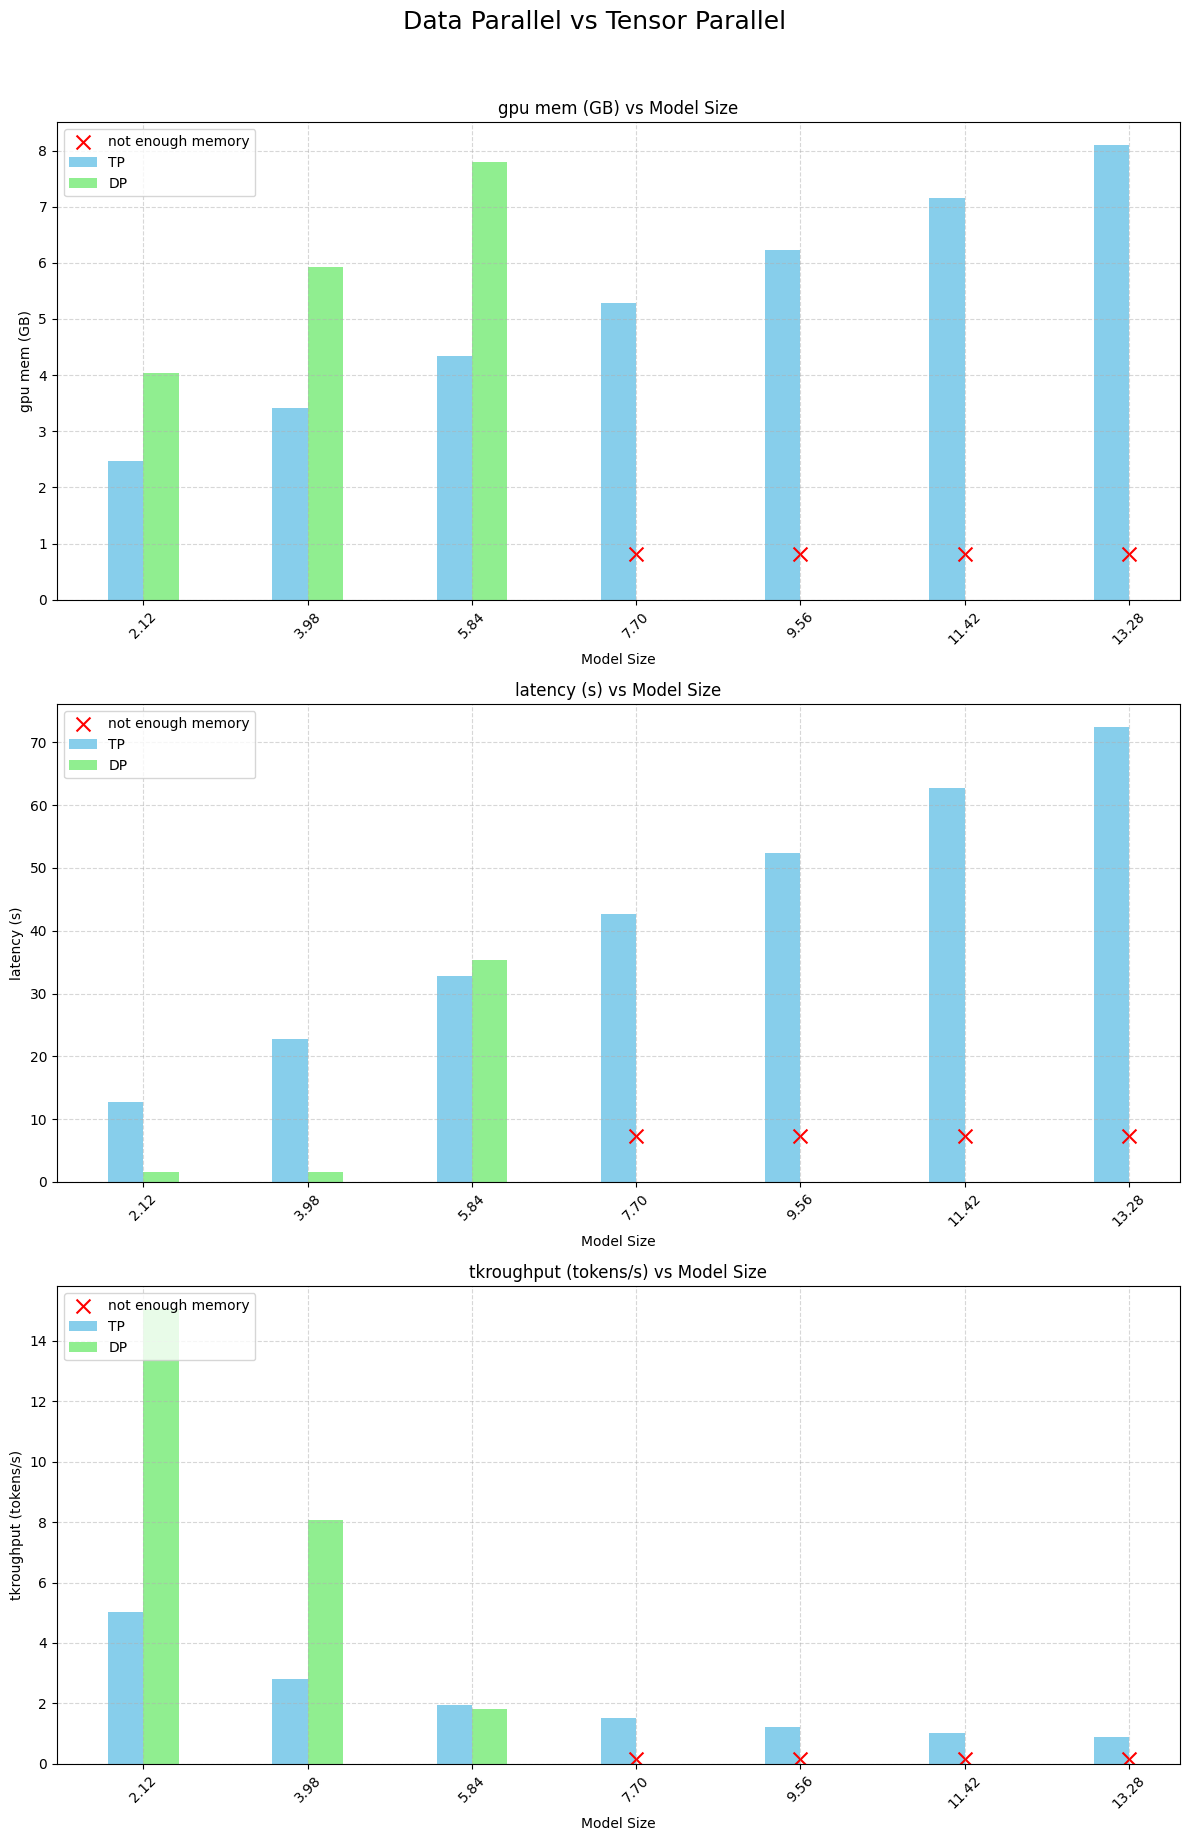

In [52]:

fig, axes = plt.subplots(len(columns), 1, figsize=(12, 18))
axes = axes.flatten()  

fig.suptitle("Data Parallel vs Tensor Parallel", fontsize=18, y=1.02)

for idx, col in enumerate(columns):
    # Объединяем данные по 'model size'
    combined = tp[["model size", col]].copy()
    combined = combined.rename(columns={col: "tp"})
    # Добавляем значения из dp, если они есть
    if col in dp.columns:
        combined["dp"] = dp[col]
    else:
        combined["dp"] = np.nan

    x = combined["model size"]
    y_tp = combined["tp"]
    y_dp = combined["dp"]

    ax = axes[idx]

    ax.bar(x - 0.2, y_tp, width=0.4, label="TP", color='skyblue')
    ax.bar(x + 0.2, y_dp, width=0.4, label="DP", color='lightgreen')

    missing_mask = pd.isna(y_dp)
    if missing_mask.any():
        y_cross = np.zeros(shape=(len(y_tp[missing_mask]),), dtype=np.float32) + 0.1 * y_tp[missing_mask].max()
        ax.scatter(x[missing_mask], y_cross, marker='x', color='red', s=100, label='not enough memory')

    ax.set_xlabel("Model Size")
    ax.set_ylabel(col)
    ax.set_title(f"{col} vs Model Size")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=45)
    ax.set_xticks(x)

plt.tight_layout()
plt.show()

In [53]:
dp_zero_cpu_eq_nvme = dp_zero_cpu[dp_zero_cpu["num layers"].isin(dp_zero_nvme["num layers"])]

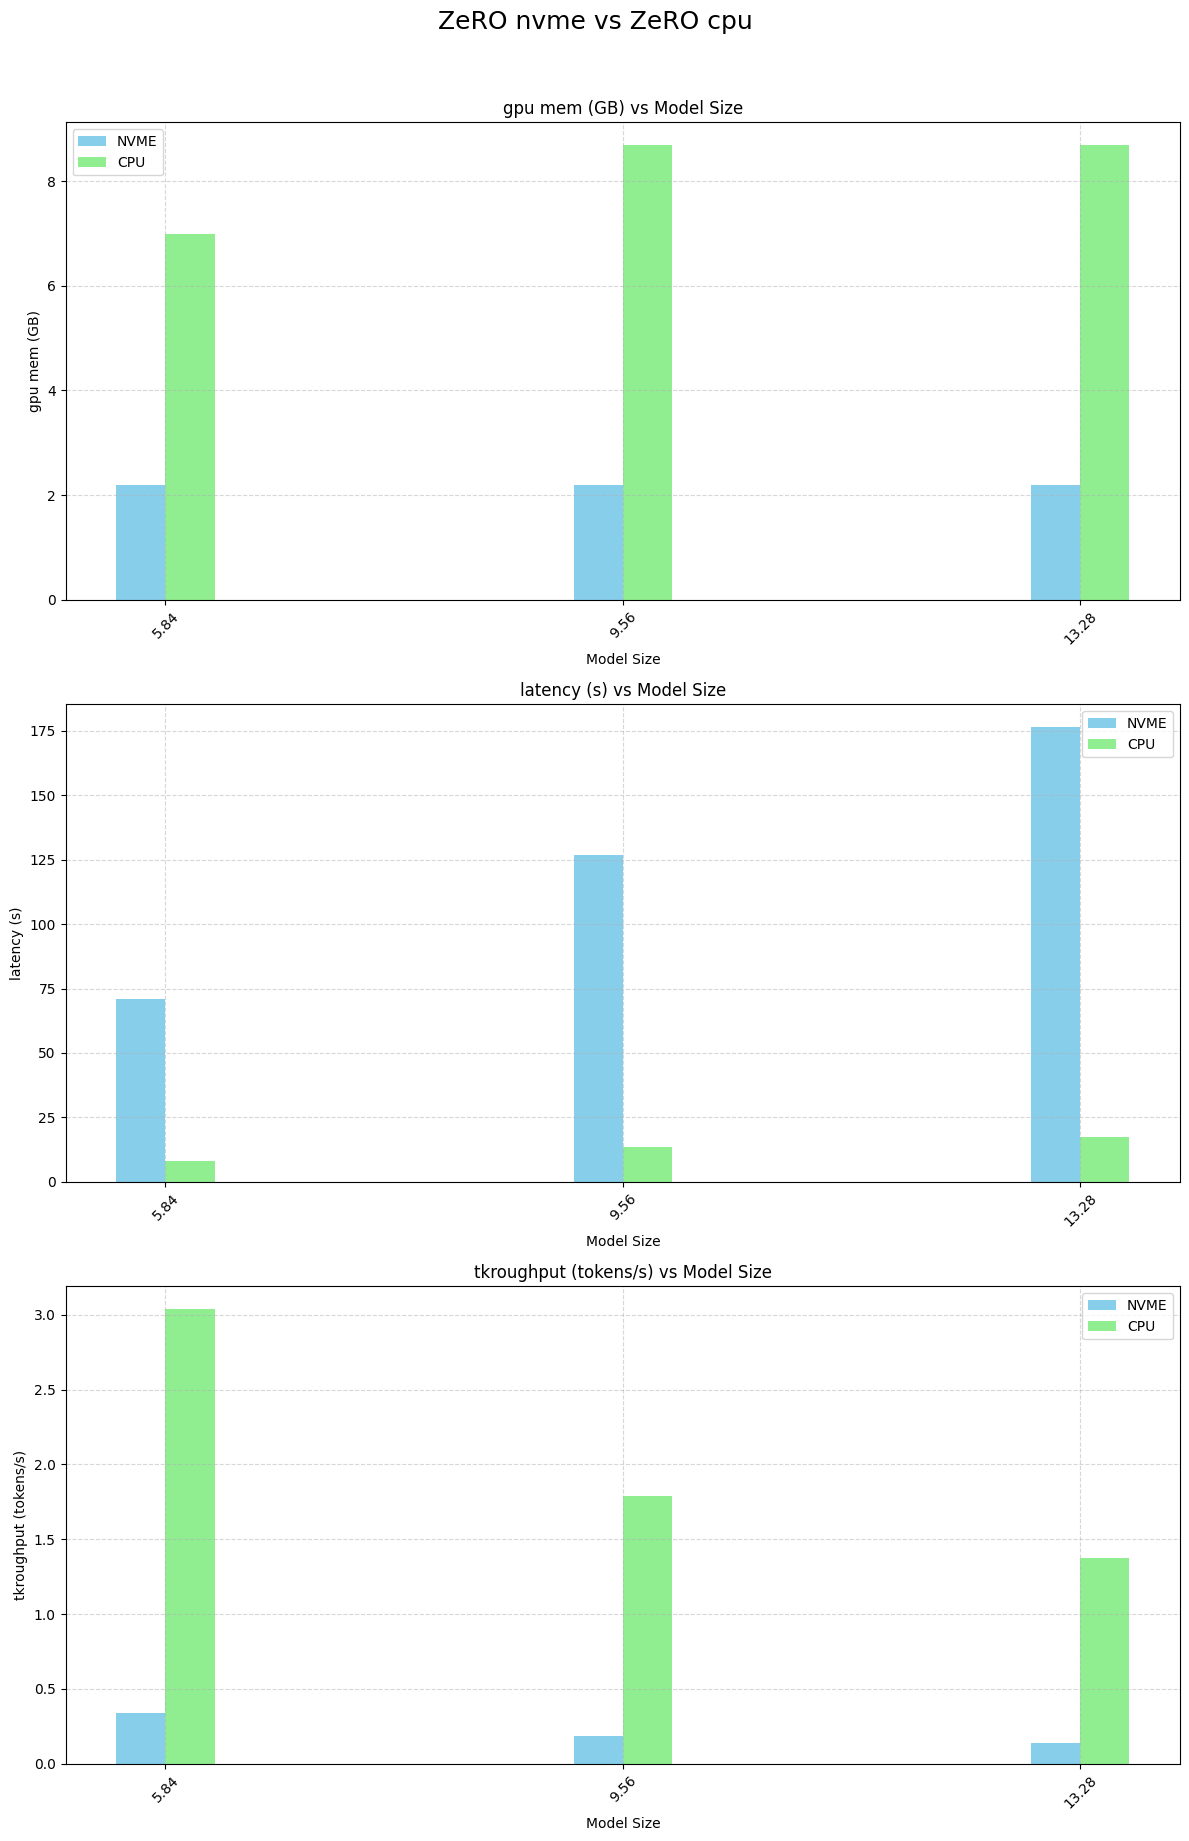

In [54]:

fig, axes = plt.subplots(len(columns), 1, figsize=(12, 18))
axes = axes.flatten()  

fig.suptitle("ZeRO nvme vs ZeRO cpu", fontsize=18, y=1.02)

for idx, col in enumerate(columns):
    combined = dp_zero_nvme[["model size", col]].copy()
    combined = combined.rename(columns={col: "nvme"})
    combined['cpu'] = dp_zero_cpu_eq_nvme[col]

    x = combined["model size"]
    y_nvme = combined["nvme"]
    y_cpu = combined["cpu"]

    ax = axes[idx]

    ax.bar(x - 0.2, y_nvme, width=0.4, label="NVME", color='skyblue')
    ax.bar(x + 0.2, y_cpu, width=0.4, label="CPU", color='lightgreen')

    missing_mask = pd.isna(y_cpu)
    if missing_mask.any():
        y_cross = np.zeros(shape=(len(y_nvme[missing_mask]),), dtype=np.float32) + 0.1 * y_tp[missing_mask].max()
        ax.scatter(x[missing_mask], y_cross, marker='x', color='red', s=100, label='Missing in dp')

    ax.set_xlabel("Model Size")
    ax.set_ylabel(col)
    ax.set_title(f"{col} vs Model Size")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=45)
    ax.set_xticks(x)

plt.tight_layout()
plt.show()

In [55]:
tp_eq_tp_zero_cpu = tp[tp["num layers"].isin(tp_zero_cpu["num layers"])].copy()

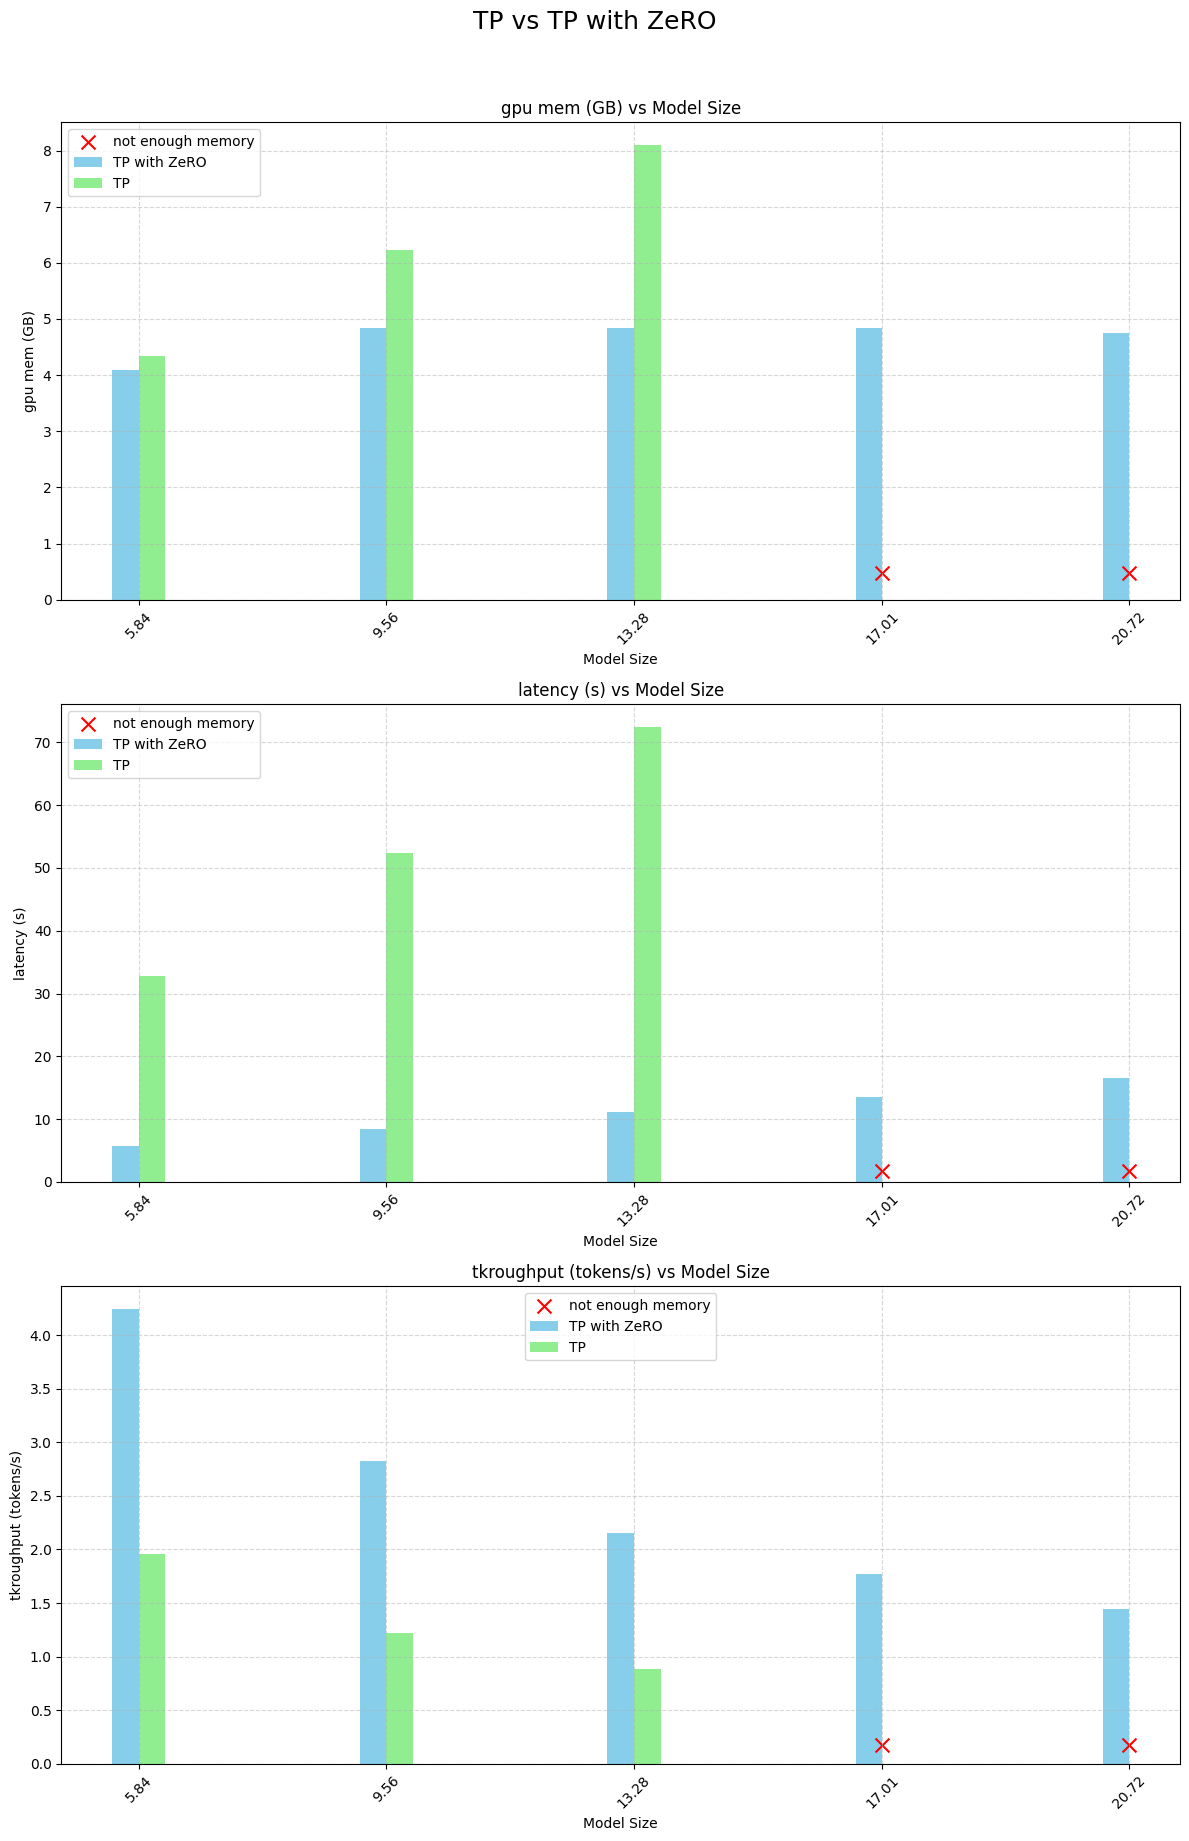

In [56]:
fig, axes = plt.subplots(len(columns), 1, figsize=(12, 18))
axes = axes.flatten()  

fig.suptitle("TP vs TP with ZeRO", fontsize=18, y=1.02)

for idx, col in enumerate(columns):
    combined = tp_zero_cpu[["model size", col]].copy()
    combined = combined.rename(columns={col: "tp_zero"})
    combined['tp'] = pd.Series(list(tp_eq_tp_zero_cpu[col]) + [np.nan, np.nan])
        

    x = combined["model size"]
    y_tp_zero = combined["tp_zero"]
    y_tp = combined["tp"]

    ax = axes[idx]

    ax.bar(x - 0.2, y_tp_zero, width=0.4, label="TP with ZeRO", color='skyblue')
    ax.bar(x + 0.2, y_tp, width=0.4, label="TP", color='lightgreen')

    missing_mask = pd.isna(y_tp)
    if missing_mask.any():
        y_cross = np.zeros(shape=(len(y_tp_zero[missing_mask]),), dtype=np.float32) + 0.1 * y_tp_zero[missing_mask].max()
        ax.scatter(x[missing_mask], y_cross, marker='x', color='red', s=100, label='not enough memory')

    ax.set_xlabel("Model Size")
    ax.set_ylabel(col)
    ax.set_title(f"{col} vs Model Size")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=45)
    ax.set_xticks(x)

plt.tight_layout()
plt.show()

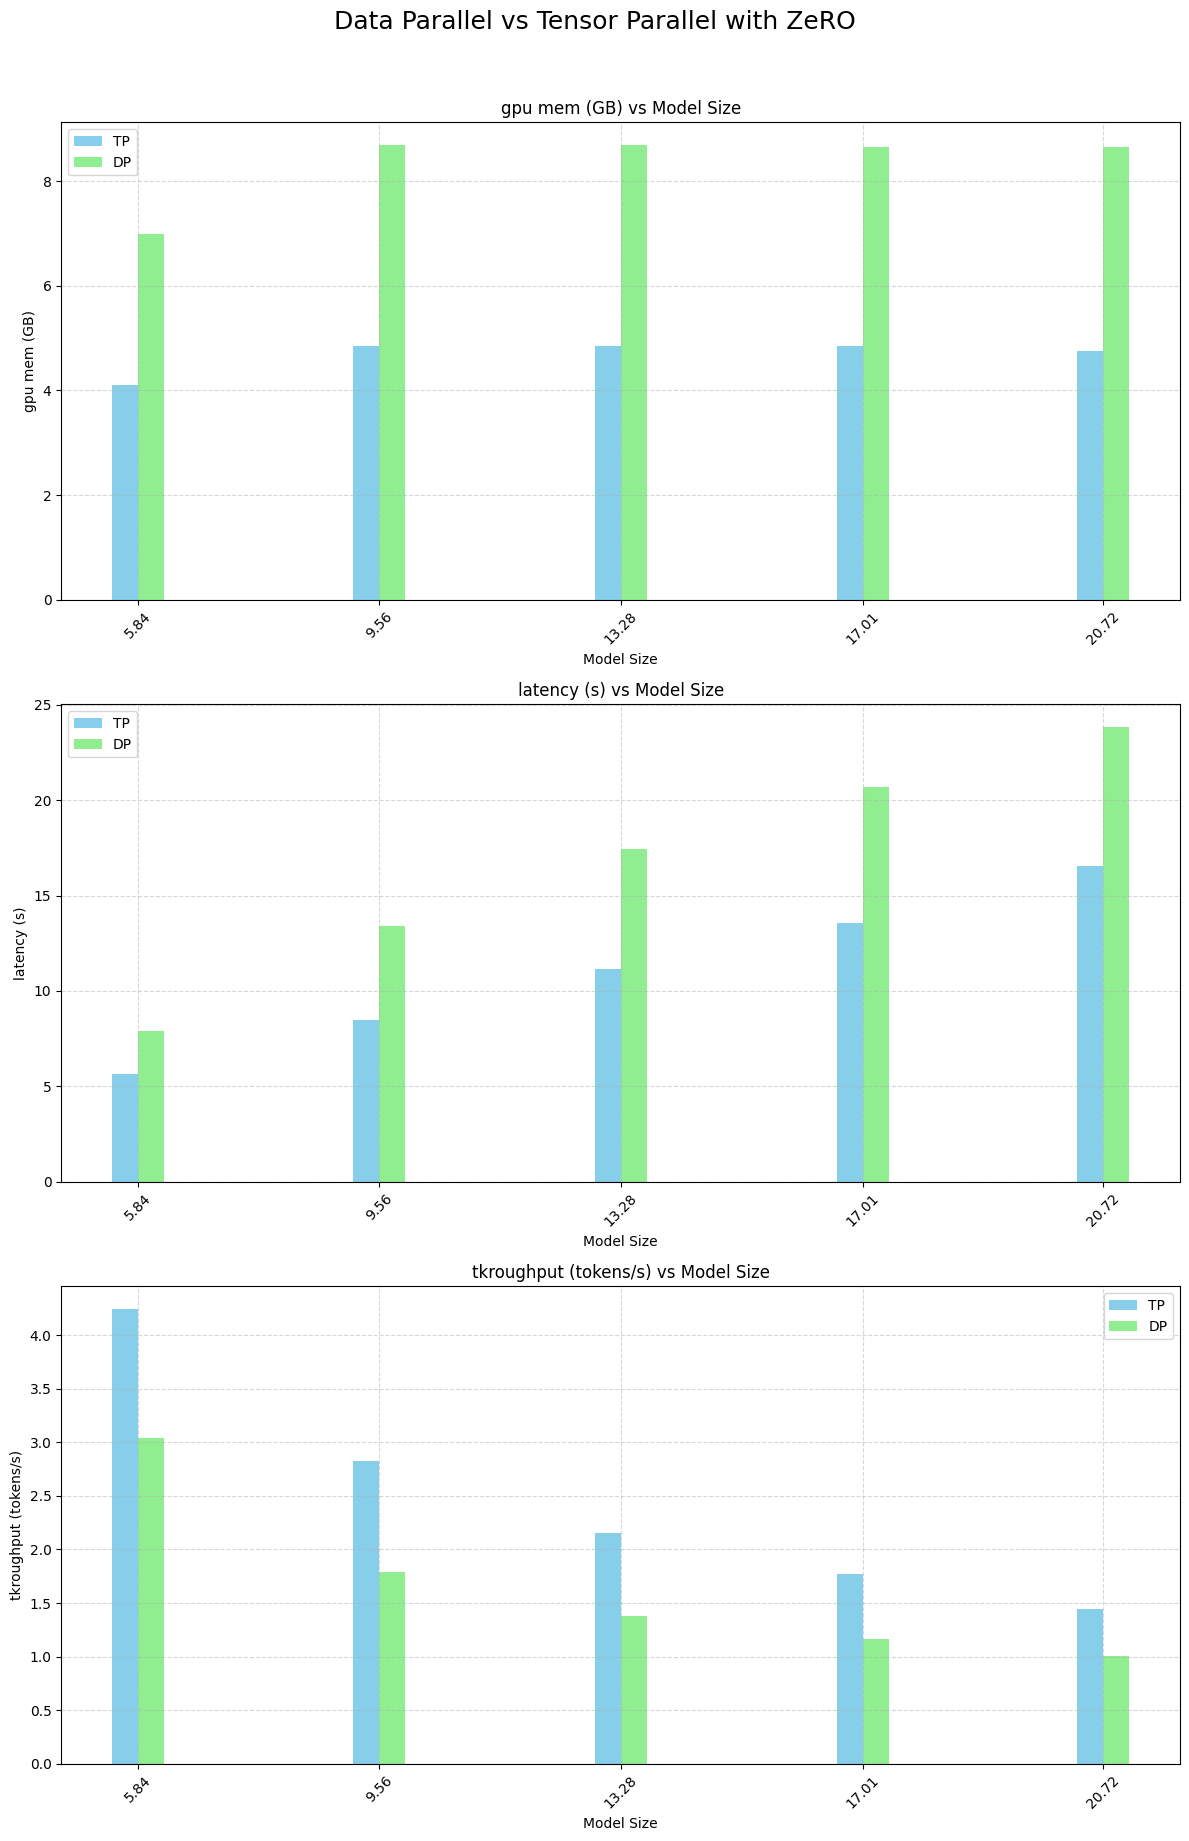

In [57]:

fig, axes = plt.subplots(len(columns), 1, figsize=(12, 18))
axes = axes.flatten()  

fig.suptitle("Data Parallel vs Tensor Parallel with ZeRO", fontsize=18, y=1.02)

for idx, col in enumerate(columns):
    # Объединяем данные по 'model size'
    combined = tp_zero_cpu[["model size", col]].copy()
    combined = combined.rename(columns={col: "tp"})
    # Добавляем значения из dp, если они есть
    if col in dp.columns:
        combined["dp"] = dp_zero_cpu[col]
    else:
        combined["dp"] = np.nan

    x = combined["model size"]
    y_tp = combined["tp"]
    y_dp = combined["dp"]

    ax = axes[idx]

    ax.bar(x - 0.2, y_tp, width=0.4, label="TP", color='skyblue')
    ax.bar(x + 0.2, y_dp, width=0.4, label="DP", color='lightgreen')

    missing_mask = pd.isna(y_dp)
    if missing_mask.any():
        y_cross = np.zeros(shape=(len(y_tp[missing_mask]),), dtype=np.float32) + 0.1 * y_tp[missing_mask].max()
        ax.scatter(x[missing_mask], y_cross, marker='x', color='red', s=100, label='Missing in dp')

    ax.set_xlabel("Model Size")
    ax.set_ylabel(col)
    ax.set_title(f"{col} vs Model Size")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=45)
    ax.set_xticks(x)

plt.tight_layout()
plt.show()

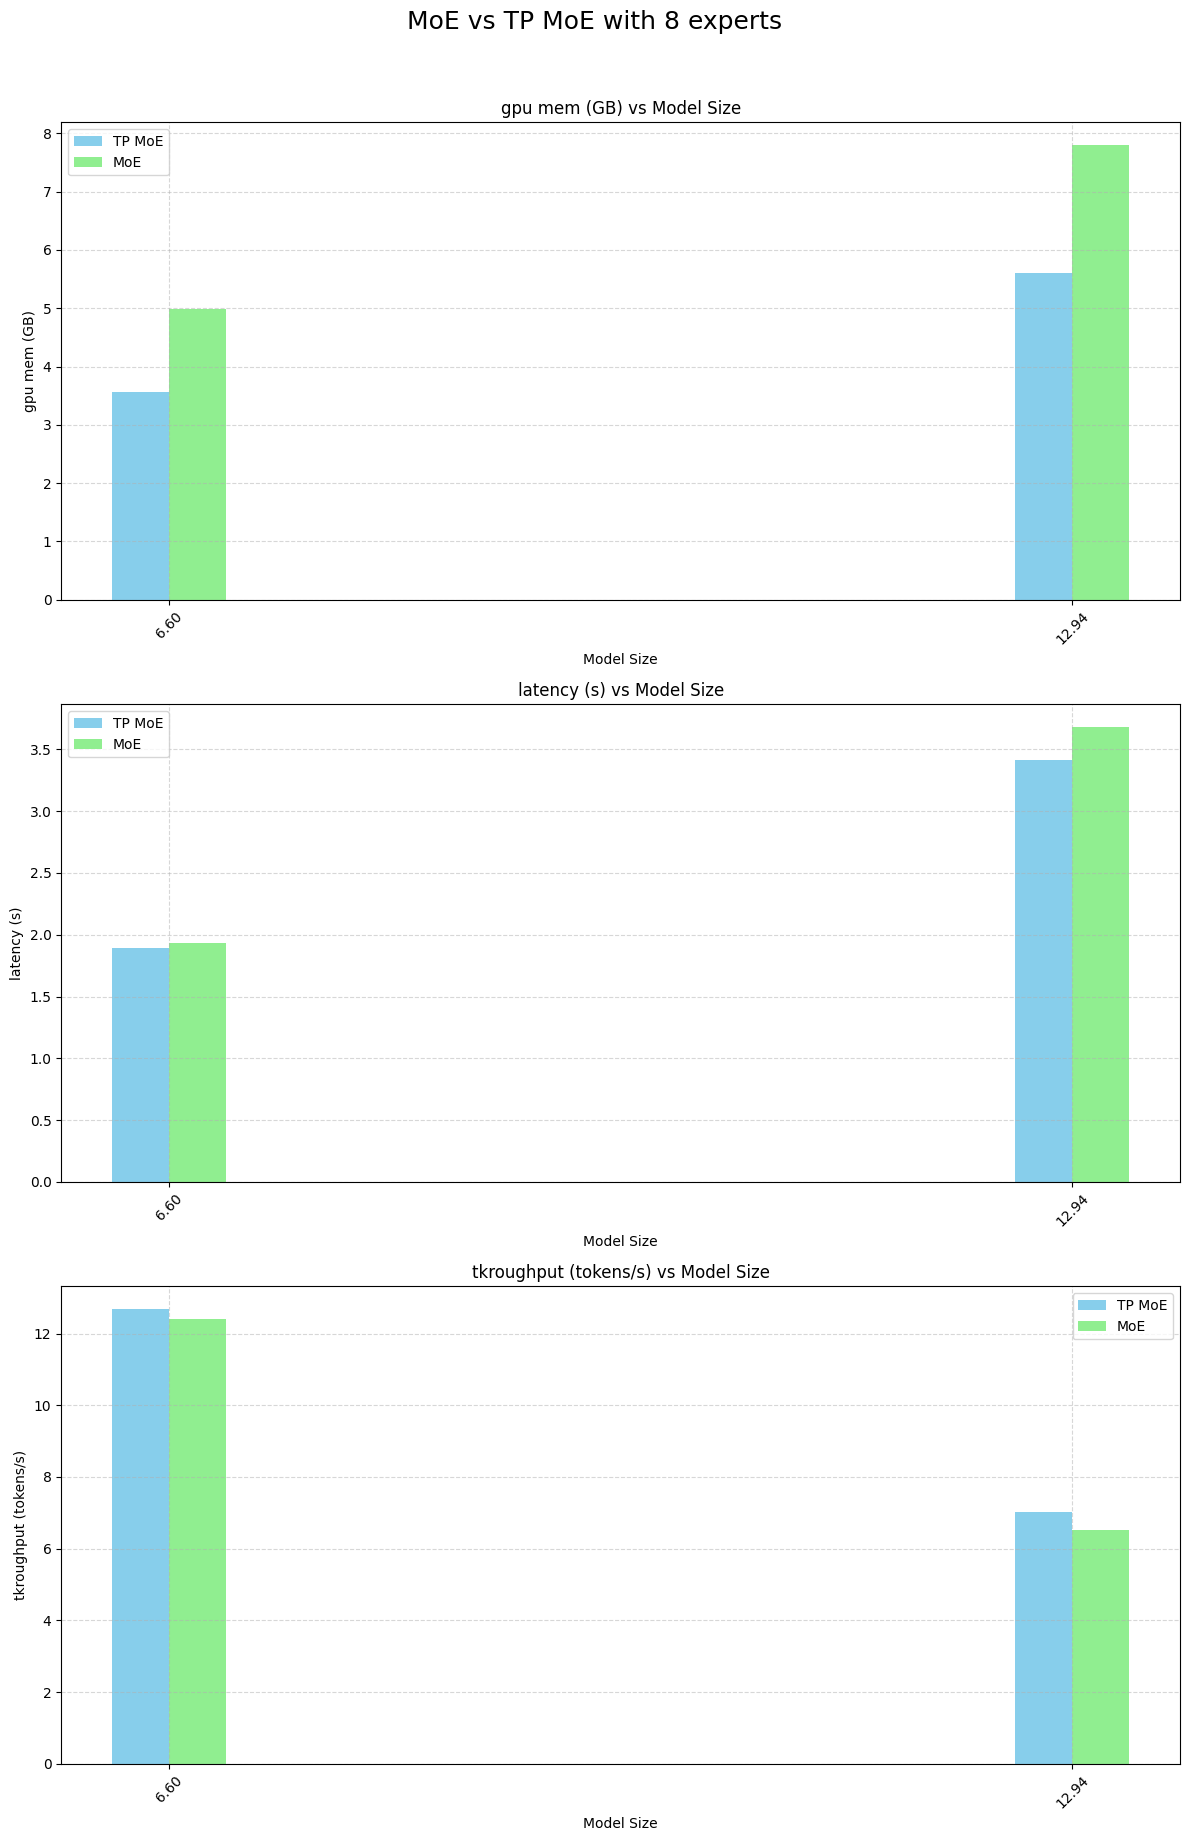

In [60]:

fig, axes = plt.subplots(len(columns), 1, figsize=(12, 18))
axes = axes.flatten()  

fig.suptitle("MoE vs TP MoE with 8 experts", fontsize=18, y=1.02)

for idx, col in enumerate(columns):
    # Объединяем данные по 'model size'
    combined = tp_moe[tp_moe["num experts"] == 8][["model size", col]].copy()
    combined = combined.rename(columns={col: "tp"})
    # Добавляем значения из dp, если они есть
    if col in dp.columns:
        combined["dp"] = moe[moe["num experts"] == 8][col]
    else:
        combined["dp"] = np.nan

    x = combined["model size"]
    y_tp = combined["tp"]
    y_dp = combined["dp"]

    ax = axes[idx]

    ax.bar(x - 0.2, y_tp, width=0.4, label="TP MoE", color='skyblue')
    ax.bar(x + 0.2, y_dp, width=0.4, label="MoE", color='lightgreen')

    missing_mask = pd.isna(y_dp)
    if missing_mask.any():
        y_cross = np.zeros(shape=(len(y_tp[missing_mask]),), dtype=np.float32) + 0.1 * y_tp[missing_mask].max()
        ax.scatter(x[missing_mask], y_cross, marker='x', color='red', s=100, label='not enough memory')

    ax.set_xlabel("Model Size")
    ax.set_ylabel(col)
    ax.set_title(f"{col} vs Model Size")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=45)
    ax.set_xticks(x)

plt.tight_layout()
plt.show()

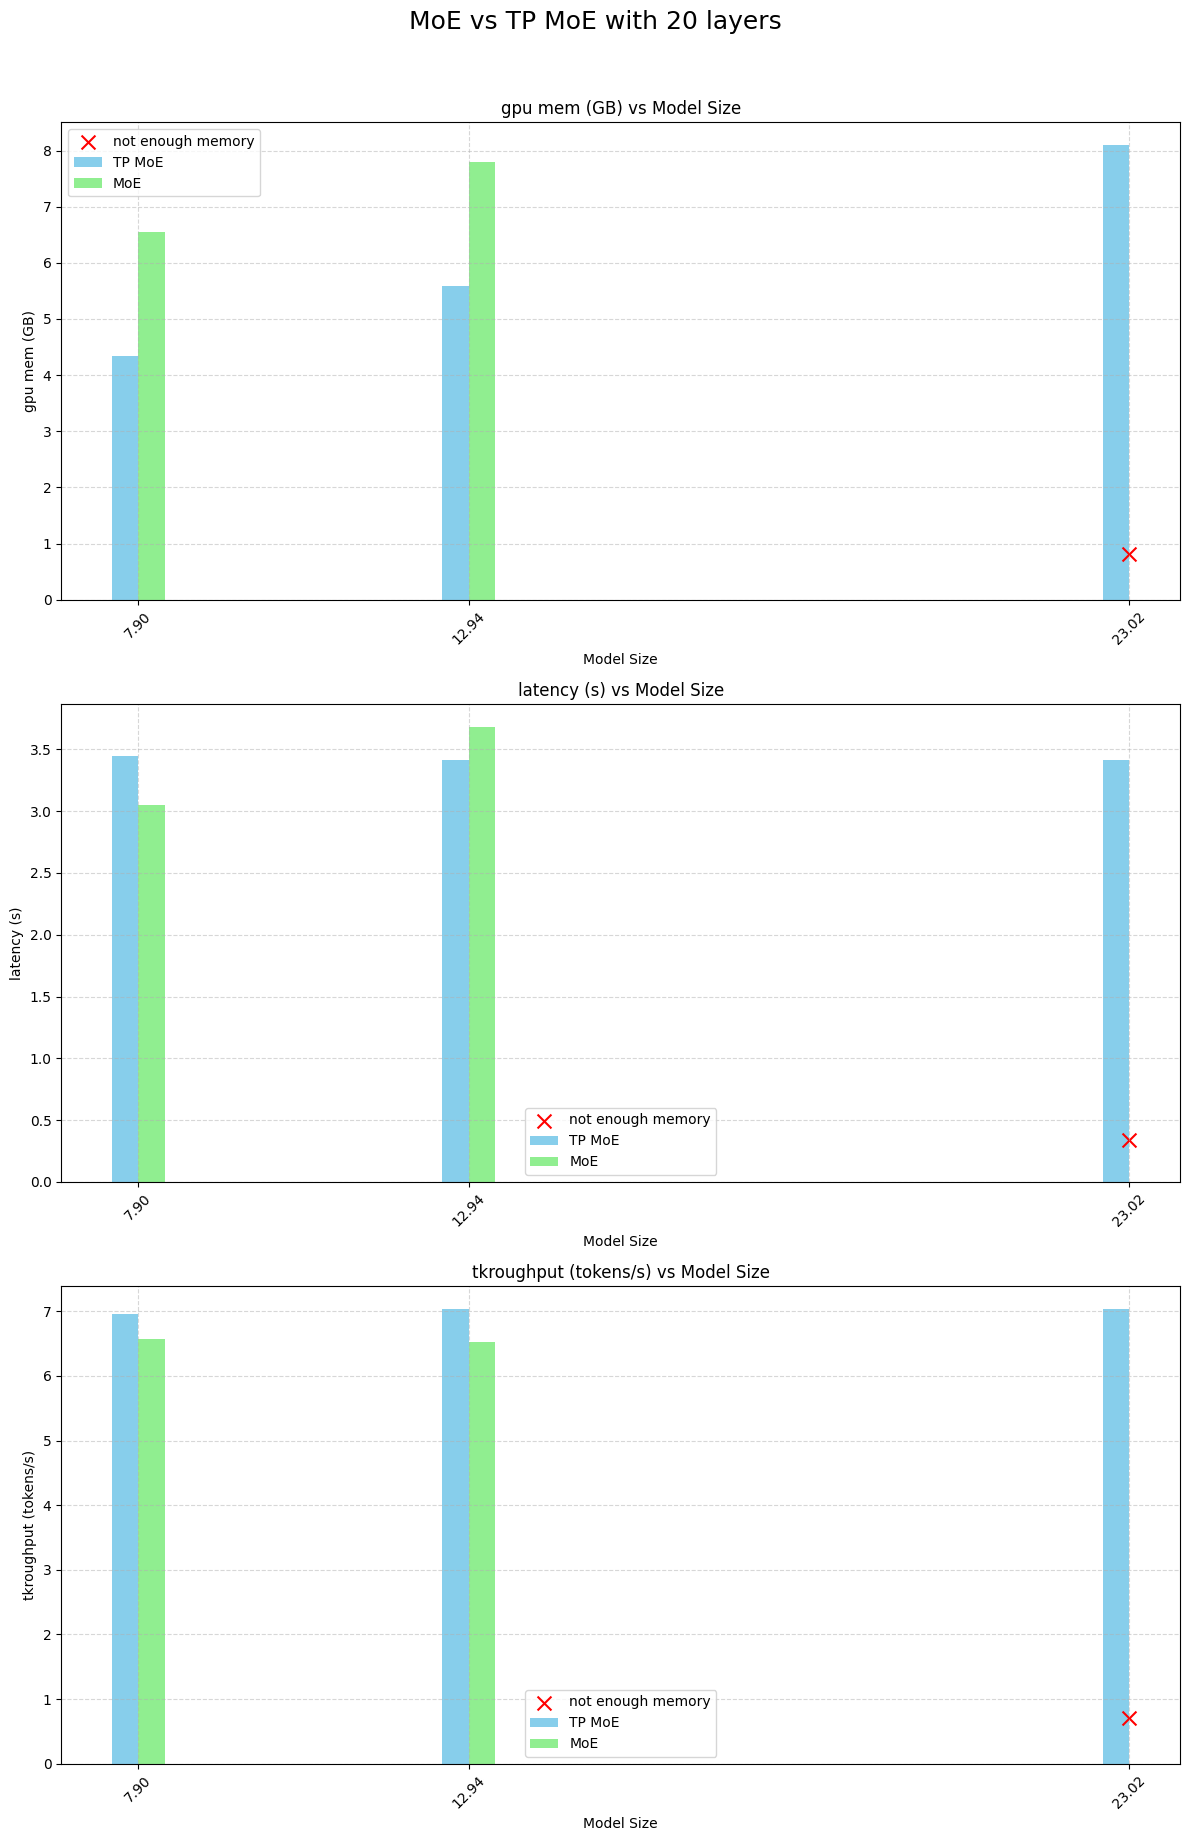

In [62]:

fig, axes = plt.subplots(len(columns), 1, figsize=(12, 18))
axes = axes.flatten()  

fig.suptitle("MoE vs TP MoE with 20 layers", fontsize=18, y=1.02)

for idx, col in enumerate(columns):
    # Объединяем данные по 'model size'
    combined = tp_moe[tp_moe["num layers"] == 20][["model size", col]].copy()
    combined = combined.rename(columns={col: "tp"})
    # Добавляем значения из dp, если они есть
    if col in dp.columns:
        combined["dp"] = moe[moe["num layers"] == 20][col]
    else:
        combined["dp"] = np.nan

    x = combined["model size"]
    y_tp = combined["tp"]
    y_dp = combined["dp"]

    ax = axes[idx]

    ax.bar(x - 0.2, y_tp, width=0.4, label="TP MoE", color='skyblue')
    ax.bar(x + 0.2, y_dp, width=0.4, label="MoE", color='lightgreen')

    missing_mask = pd.isna(y_dp)
    if missing_mask.any():
        y_cross = np.zeros(shape=(len(y_tp[missing_mask]),), dtype=np.float32) + 0.1 * y_tp[missing_mask].max()
        ax.scatter(x[missing_mask], y_cross, marker='x', color='red', s=100, label='not enough memory')

    ax.set_xlabel("Model Size")
    ax.set_ylabel(col)
    ax.set_title(f"{col} vs Model Size")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=45)
    ax.set_xticks(x)

plt.tight_layout()
plt.show()

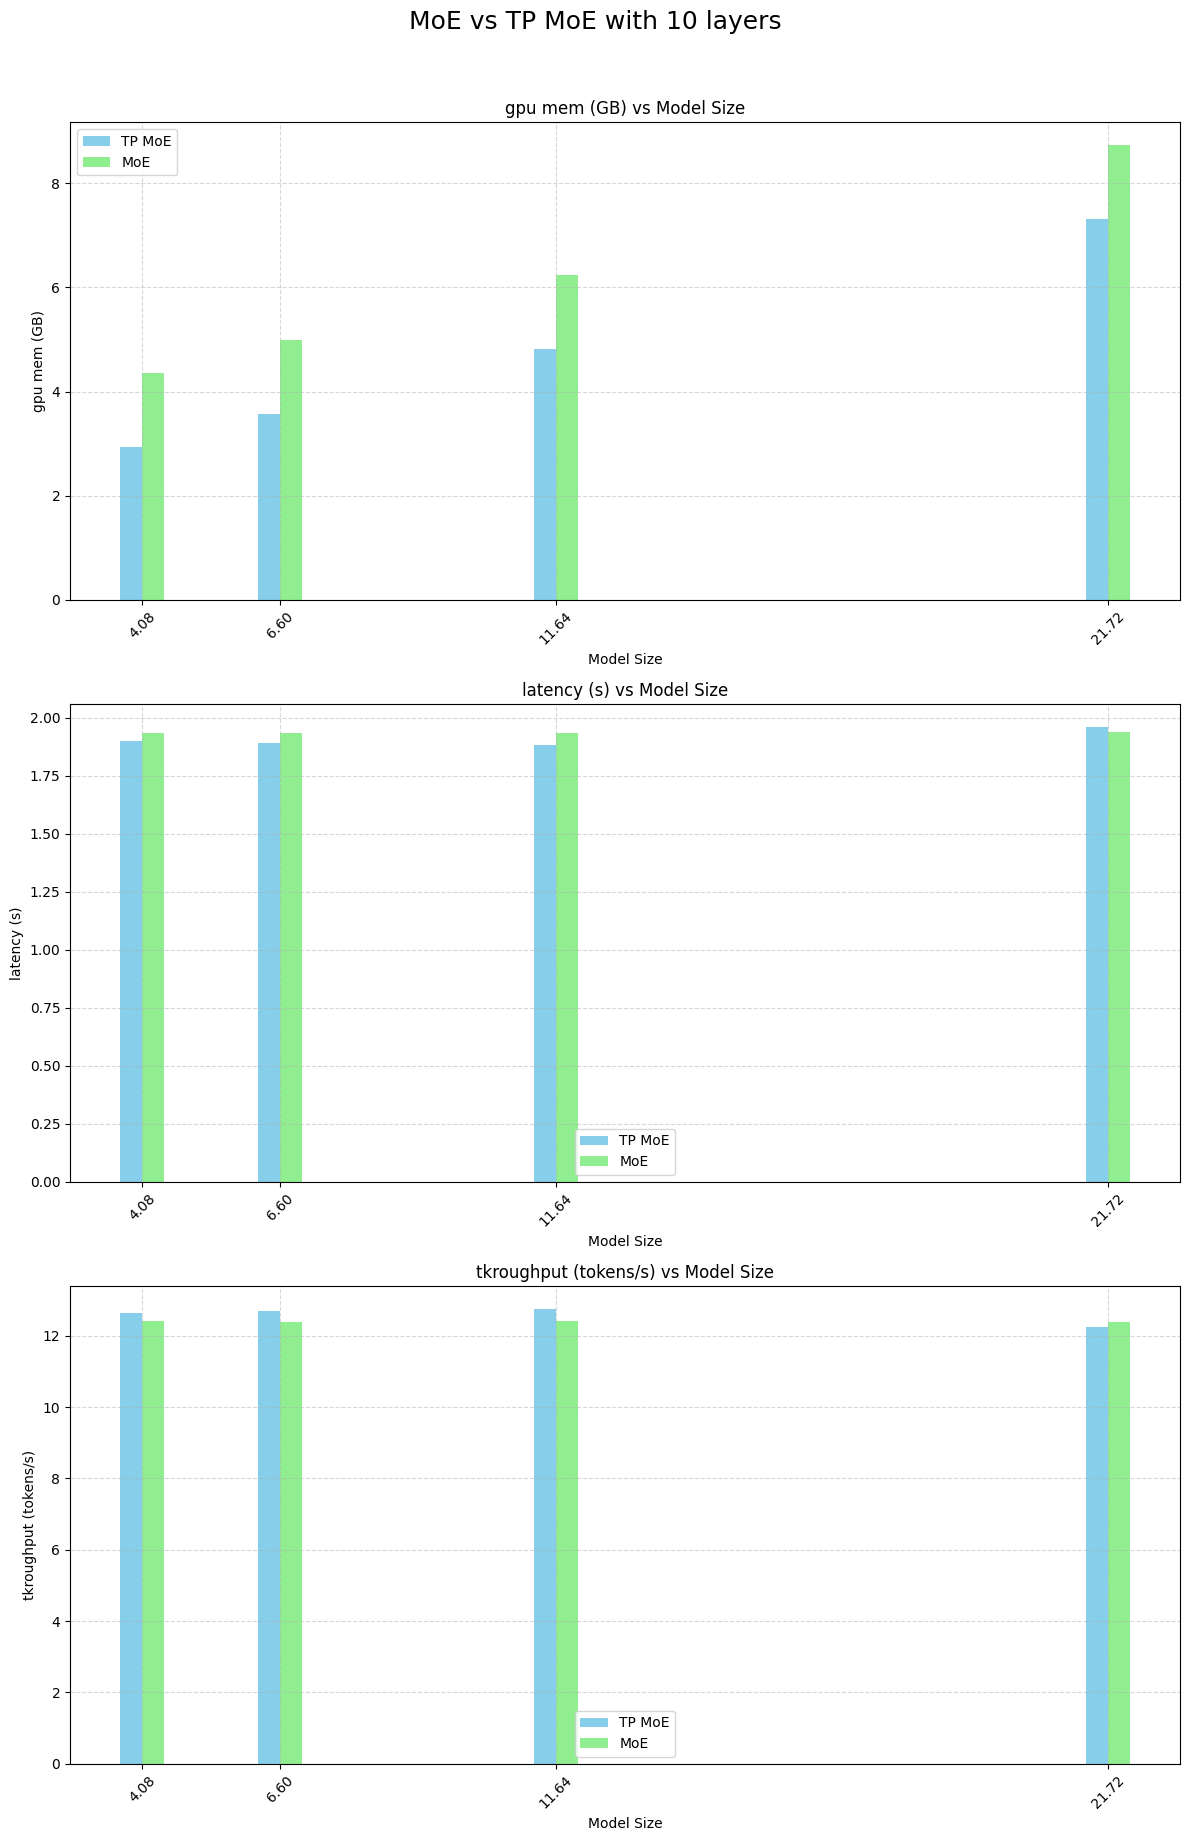

In [65]:

fig, axes = plt.subplots(len(columns), 1, figsize=(12, 18))
axes = axes.flatten()  

fig.suptitle("MoE vs TP MoE with 10 layers", fontsize=18, y=1.02)

for idx, col in enumerate(columns):
    # Объединяем данные по 'model size'
    combined = tp_moe[tp_moe["num layers"] == 10][["model size", col]].copy()
    combined = combined.rename(columns={col: "tp"})
    # Добавляем значения из dp, если они есть
    if col in dp.columns:
        combined["dp"] = moe[moe["num layers"] == 10][col]
    else:
        combined["dp"] = np.nan

    x = combined["model size"]
    y_tp = combined["tp"]
    y_dp = combined["dp"]

    ax = axes[idx]

    ax.bar(x - 0.2, y_tp, width=0.4, label="TP MoE", color='skyblue')
    ax.bar(x + 0.2, y_dp, width=0.4, label="MoE", color='lightgreen')

    missing_mask = pd.isna(y_dp)
    if missing_mask.any():
        y_cross = np.zeros(shape=(len(y_tp[missing_mask]),), dtype=np.float32) + 0.1 * y_tp[missing_mask].max()
        ax.scatter(x[missing_mask], y_cross, marker='x', color='red', s=100, label='not enough memory')

    ax.set_xlabel("Model Size")
    ax.set_ylabel(col)
    ax.set_title(f"{col} vs Model Size")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=45)
    ax.set_xticks(x)

plt.tight_layout()
plt.show()